#Exploring Tire Degradation
How much time do drivers lose per lap to tire degradation?
    How does that change with tire compound?
Starting with the 2025 Italian GP at Monza.

In [32]:
#Imports and cache
import fastf1
import pandas as pd
import matplotlib.pyplot as plt

fastf1.Cache.enable_cache('../cache')

In [33]:
#Load race
session = fastf1.get_session(2025, 'Monza', 'R')
session.load()
laps = session.laps

core           INFO 	Loading data for Italian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 27)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '81', '16', '63', '44', '23', '5', '12', '6', '55', '87', '22', '3

In [34]:
print(laps.shape)
laps[['Driver', 'LapNumber', 'LapTime', 'Compound', 'TyreLife', 'Stint', 'PitInTime']].head(50)

(974, 31)


,Driver,LapNumber,LapTime,Compound,TyreLife,Stint,PitInTime
0,VER,1.0,0 days 00:01:27.159000,MEDIUM,1.0,1.0,NaT
1,VER,2.0,0 days 00:01:24.859000,MEDIUM,2.0,1.0,NaT
2,VER,3.0,0 days 00:01:23.512000,MEDIUM,3.0,1.0,NaT
3,VER,4.0,0 days 00:01:23.262000,MEDIUM,4.0,1.0,NaT
4,VER,5.0,0 days 00:01:23.588000,MEDIUM,5.0,1.0,NaT
5,VER,6.0,0 days 00:01:23.576000,MEDIUM,6.0,1.0,NaT
6,VER,7.0,0 days 00:01:23.310000,MEDIUM,7.0,1.0,NaT
7,VER,8.0,0 days 00:01:23.139000,MEDIUM,8.0,1.0,NaT
8,VER,9.0,0 days 00:01:23.101000,MEDIUM,9.0,1.0,NaT
9,VER,10.0,0 days 00:01:23.088000,MEDIUM,10.0,1.0,NaT


In [ ]:
print("#Laps: ", session.total_laps)
print("#Drivers: ", len(session.drivers))
laps['Compound'].value_counts()



#Laps:  53
#Drivers:  20


np.int64(0)

In [42]:
print(laps['Compound'].value_counts() )          # which tires were used, and how much
print(laps['LapTime'].isna().sum())              # how many laps have no time
(laps[laps['LapTime'].isna()][['Driver', 'LapNumber', 'PitInTime', 'TrackStatus']])

Compound
HARD      516
MEDIUM    427
SOFT       31
Name: count, dtype: int64
0


,Driver,LapNumber,PitInTime,TrackStatus


All compounds were used, with 516 HARD, 427 MEDIUM, and 31 SOFTs

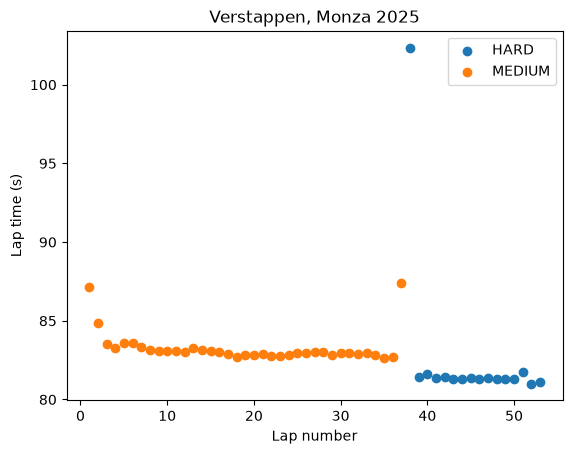

In [41]:
laps['LapTimeSec'] = laps['LapTime'].dt.total_seconds()
ver = laps[laps['Driver'] == 'VER']

for compound, group in ver.groupby('Compound'):
    plt.scatter(group['LapNumber'], group['LapTimeSec'], label=compound)

plt.xlabel('Lap number')
plt.ylabel('Lap time (s)')
plt.title('Verstappen, Monza 2025')
plt.legend()
plt.show()

In [43]:
clean = laps.pick_wo_box()              # remove in-laps and out-laps
clean = clean.pick_track_status('1')    # keep only green-flag laps
clean = clean.pick_quicklaps()          # remove laps >107% of the fastest lap
clean = clean[clean['LapNumber'] > 1]   # remove the standing-start lap

print(len(laps), '->', len(clean))



974 -> 894


Filtering removed 80 laps, which tracks with removing in-laps and out laps for all drivers

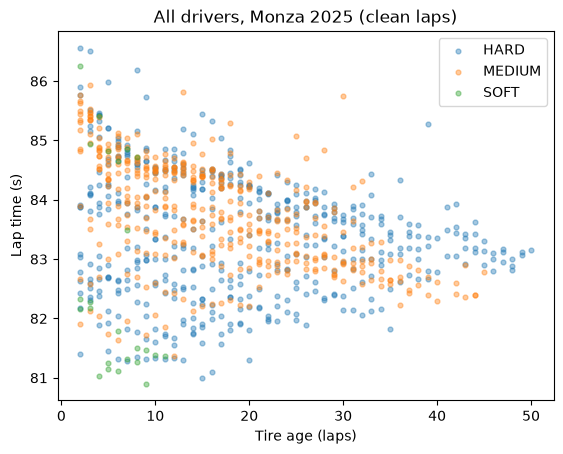

In [44]:
for compound, group in clean.groupby('Compound'):
    plt.scatter(group['TyreLife'], group['LapTimeSec'], label=compound, alpha=0.4, s=12)

plt.xlabel('Tire age (laps)')
plt.ylabel('Lap time (s)')
plt.title('All drivers, Monza 2025 (clean laps)')
plt.legend()
plt.show()

The spread gets tighter the more the tires age, but the overall trend goes down. There are also visible stripes sloping downward as laps increase. There were few laps on the SOFT compound, so we probably can't draw any conclusions about it.

Now we'll try to fit a model to predict lap time based on a number of parameters. From visible trends, I predict that as LapNumber increases, lap time will decrease, as the burning of fuel will cause more gains than the degradation of the tires will cause slow downs. I also predict that MEDIUM should be more affected by tire degradation than HARD, given the nature of the tire compounds.

In [45]:
from sklearn.linear_model import LinearRegression

df = clean[['Driver', 'LapNumber', 'TyreLife', 'Compound', 'LapTimeSec']].dropna()
df = df[df['Compound'].isin(['MEDIUM', 'HARD'])]   # too few soft laps

# One-hot encode driver and compound (base pace per driver, offset per compound)
X = pd.get_dummies(df[['Driver', 'Compound']], drop_first=True).astype(float)
X['LapNumber'] = df['LapNumber']
for c in ['MEDIUM', 'HARD']:
    X[f'TyreLife_{c}'] = df['TyreLife'] * (df['Compound'] == c)

y = df['LapTimeSec']
model = LinearRegression().fit(X, y)

coefs = pd.Series(model.coef_, index=X.columns)
print(coefs[['LapNumber', 'TyreLife_MEDIUM', 'TyreLife_HARD']])
print('R^2:', model.score(X, y))

LapNumber         -0.062668
TyreLife_MEDIUM    0.018225
TyreLife_HARD      0.014655
dtype: float64
R^2: 0.8714624533643206


It appears my predictions were correct. As lapNumber increases, lap times decrease by 5 hundredths (likely due to fuel burn as noted earlier), and MEDIUMs were more affected than HARDs, losing 4 hundreths more per lap on average. The R^2 of 0.87 would usually mean the model fits the data pretty well, but this is likely due to it overfitting, as it was measured on the same data it was trained on.  We can run confidence intervals to confirm that the difference in compounds isn't due to chance.

In [46]:
import statsmodels.formula.api as smf

res = smf.ols(
    'LapTimeSec ~ C(Driver) + C(Compound) + LapNumber + TyreLife:C(Compound)',
    data=df
).fit()

rows = [name for name in res.params.index if 'TyreLife' in name or name == 'LapNumber']
summary = pd.concat([res.params[rows], res.conf_int().loc[rows]], axis=1)
summary.columns = ['estimate', 'low_95', 'high_95']
summary

,estimate,low_95,high_95
LapNumber,-0.062668,-0.065282,-0.060055
TyreLife:C(Compound)[HARD],0.014655,0.010916,0.018394
TyreLife:C(Compound)[MEDIUM],0.018225,0.013909,0.022540


Both compounds show measurable wear, but their confidence intervals overlap heavily, so we can't tell whether the MEDIUMs degrade faster than the HARDs from this race alone. We can further confirm with the p-value of the difference.

In [50]:
print(res.t_test('TyreLife:C(Compound)[MEDIUM] - TyreLife:C(Compound)[HARD] = 0'))

                             Test for Constraints                             
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
c0             0.0036      0.003      1.415      0.157      -0.001       0.009


At .15, it is not statistically significant, and therefore likely to have occured by chance.